# Importación de librerias

In [ ]:
def separador():
    print("\n" + "=" * 170 + "\n")
def header(Titulo):
  por=((170-len(Titulo))//10)
  a=int(1.2*por)
  print("."*a+"·"*a+"~"*a+"≈"*a+"≋"
  *int(por*.2),Titulo,"≋"*int(por*.2)
  +"≈"*a+"~"*a+"·"*a+"."*a,"\n\n")

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.9 MB/s eta 0:00:00


In [ ]:
import re
#dataset
from sklearn.datasets import fetch_20newsgroups

from gensim.models import Word2Vec
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score,calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser','ner']) #no se necesitan

# Dataset

In [ ]:
nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])
dataset=fetch_20newsgroups(subset='all',remove=('headers','footers','quotes'))
docs_raw=dataset.data
print("Cantidad de documentos: ",len(docs_raw))

Cantidad de documentos:  18846


# Preprocesamiento del texto

In [ ]:
#se minimiza, se quitan urls, menciones y hashtags dejando solo alfanuméricos, se tokeniza y se lematiza con el procesamiento de arriba.
def preprocesamiento (texto):
  doc=nlp(texto)
  tokens_lematizados=[] #para ir rellenandola
  for token in doc: #lo que hace la siguiente linea: quita puntuaciones, url, correos y palabras cortas.
    if (token.is_stop or token.is_punct or token.like_url or token.like_email or not token.is_alpha or len(token.text)<=2):
      continue
    tokens_lematizados.append(token.lemma_) #regresa el lemma en minusculas
  return tokens_lematizados
docs_tokenizados=[preprocesamiento(doc) for doc in docs_raw]
modelo_w2v=Word2Vec(docs_tokenizados,vector_size=100) #vector de 100



##  vectores de documentos

In [ ]:
def vector_documento(doc_tokens,modelo):
  vectores_pal=[modelo.wv[token] for token in doc_tokens if token in modelo.wv]
  if not vectores_pal:
    return np.zeros(modelo.vector_size)
  return np.mean(vectores_pal,axis=0)

vectores_docs=np.array([vector_documento(doc,modelo_w2v) for doc in docs_tokenizados])

#Kmeans & Silhouette Score

..................··················~~~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋≋ Método del codo ≋≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~~~··················.................. 




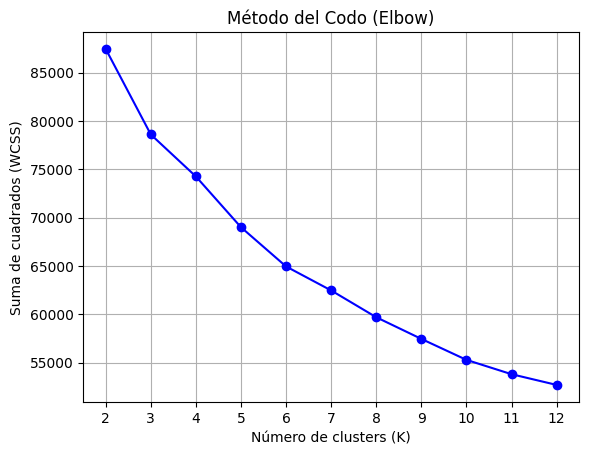

................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Coeficiente de Silhouette ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 


K=2, Silhouette Score: 0.223
K=3, Silhouette Score: 0.151
K=4, Silhouette Score: 0.136
K=5, Silhouette Score: 0.147
K=6, Silhouette Score: 0.152
K=7, Silhouette Score: 0.136
K=8, Silhouette Score: 0.15
K=9, Silhouette Score: 0.141
K=10, Silhouette Score: 0.151
K=11, Silhouette Score: 0.146
K=12, Silhouette Score: 0.145




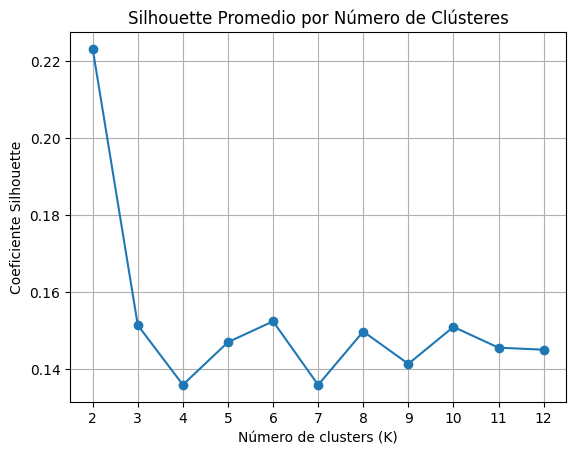

In [ ]:
header('Método del codo')
wcss=[]
K=range(2,13)
for k in K:
  kmeans=KMeans(n_clusters=k,random_state=9)
  kmeans.fit(vectores_docs)
  wcss.append(kmeans.inertia_)

plt.plot(K,wcss,'-bo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Suma de cuadrados (WCSS)')
plt.title('Método del Codo (Elbow)')
marcas_x=range(2,13,1)
plt.xticks(marcas_x)
plt.grid(True)
plt.show()
#=====================================================================#
header('Coeficiente de Silhouette')
sil_scores=[]
for k in range (2,13):
  kmeans=KMeans(n_clusters=k,random_state=9)
  labels=kmeans.fit_predict(vectores_docs)
  score=silhouette_score(vectores_docs,labels)
  sil_scores.append(score)
  print(f'K={k}, Silhouette Score: {round(score,3)}')
separador()
plt.plot(range(2,13),sil_scores,'-o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Coeficiente Silhouette')
plt.title('Silhouette Promedio por Número de Clústeres')
marcas_x=range(2,13,1)
plt.xticks(marcas_x)
plt.grid(True)
plt.show()


## Mejor Kmeans y métricas

In [ ]:
#La reducción de la inercia se estabiliza en k=6, uno de los valores mayores de k tambien ocurre en k=6, ergo el mejor valor es 6
header('Kmeans con 6 clusters')
from collections import Counter
kmeans=KMeans(n_clusters=6,random_state=9)
kmeans.fit(vectores_docs)
conteo_clusters=Counter(kmeans.labels_)
for cluster_id in sorted (conteo_clusters.keys()):
  total_documentos=conteo_clusters[cluster_id]
  print(f'Cluster {cluster_id+1}: {total_documentos} documentos')

header('Métricas de desempeño')
sil_kmeans = silhouette_score(vectores_docs, kmeans.labels_)
db_kmeans = davies_bouldin_score(vectores_docs, kmeans.labels_)
ch_kmeans = calinski_harabasz_score(vectores_docs, kmeans.labels_)

print(f"Silhouette: {sil_kmeans:.4f}")
print(f"Davies-Bouldin: {db_kmeans:.4f}")
print(f"Calinski-Harabasz: {ch_kmeans:.4f}");separador()

................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Kmeans con 6 clusters ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 


Cluster 1: 4704 documentos
Cluster 2: 1857 documentos
Cluster 3: 2869 documentos
Cluster 4: 2475 documentos
Cluster 5: 1586 documentos
Cluster 6: 5355 documentos



métricas de desempeño
Silhouette: 0.1524
Davies-Bouldin: 1.8945
Calinski-Harabasz: 2711.5580




# DBSCAN en eps 2.5 y min_samples=15

In [ ]:
def dbscan (eps,min_samples):

  dbscan=DBSCAN(eps=eps,min_samples=min_samples)
  labels_dbscan=dbscan.fit_predict(vectores_docs)
  n_clusters_dbscan=len(set(labels_dbscan))- (1 if -1 in labels_dbscan else 0)
  n_ruido=list(labels_dbscan).count(-1)
  print(f"DBSCAN encontró {n_clusters_dbscan} clusters y {n_ruido} puntos de ruido.")
  if n_clusters_dbscan>1: #para que solo imprima en buenos valores, de lo contario lo omite
    puntos_cluster=vectores_docs[labels_dbscan != -1]
    etiquetas_cluster=labels_dbscan[labels_dbscan != -1]
    sil_dbscan=silhouette_score(puntos_cluster,etiquetas_cluster)
    db_dbscan=davies_bouldin_score(puntos_cluster,etiquetas_cluster)
    ch_dbscan=calinski_harabasz_score(puntos_cluster,etiquetas_cluster)
    print(f"Silhouette: {sil_dbscan:.4f}")
    print(f"Davies-Bouldin: {db_dbscan:.4f}")
    print(f"Calinski-Harabasz: {ch_dbscan:.4f}");
    separador()
print('eps=2.5, min_samples=15')
dbscan(2.5,15)
print('eps=1.5, min_samples=20')
dbscan(1.5,20)
print('eps=2.0, min_samples=20')
dbscan(2.0,20)
print('eps=2.5, min_samples=50')
dbscan(2.5,50)

DBSCAN encontró 1 clusters y 187 puntos de ruido.
DBSCAN encontró 1 clusters y 1632 puntos de ruido.
DBSCAN encontró 1 clusters y 458 puntos de ruido.
DBSCAN encontró 1 clusters y 200 puntos de ruido.


## Mas valores

In [ ]:
print('eps=1.0, min_samples=20')
dbscan(2.5,20)
print('eps=.8, min_samples=20')
dbscan(.8,20)
print('eps=.5, min_samples=20')
dbscan(.5,20)


eps=1.0, min_samples=20
DBSCAN encontró 1 clusters y 193 puntos de ruido.
eps=.8, min_samples=20
DBSCAN encontró 3 clusters y 13734 puntos de ruido.
Silhouette: 0.1864
Davies-Bouldin: 1.1234
Calinski-Harabasz: 444.6072


eps=.5, min_samples=20
DBSCAN encontró 1 clusters y 18229 puntos de ruido.


## Exploración alrededor de eps=.8 y min_samples=20

In [ ]:
print('eps=.8, min samples=25')
dbscan(.8,25)
print('eps=.75, min samples=20')
dbscan(.75,20)

eps=.8, min samples=25
DBSCAN encontró 3 clusters y 14130 puntos de ruido.
Silhouette: 0.3525
Davies-Bouldin: 0.9957
Calinski-Harabasz: 1863.2776


eps=.75, min samples=20
DBSCAN encontró 4 clusters y 15231 puntos de ruido.
Silhouette: 0.2671
Davies-Bouldin: 1.0736
Calinski-Harabasz: 1270.8096




**Considero que el ganador es eps=.8 y min_samples=20.**

In [ ]:
best_eps = 0.8
best_min_samples = 25

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
labels_dbscan_final = dbscan_final.fit_predict(vectores_docs)


puntos_cluster = vectores_docs[labels_dbscan_final != -1]
etiquetas_cluster = labels_dbscan_final[labels_dbscan_final != -1]

#Guardar métricas en variables para crear el df comparativo
sil_dbscan = silhouette_score(puntos_cluster, etiquetas_cluster)
db_dbscan = davies_bouldin_score(puntos_cluster, etiquetas_cluster)
ch_dbscan = calinski_harabasz_score(puntos_cluster, etiquetas_cluster)

# Comparación de resultados:

In [ ]:
data_metricas = {
    'K-Means (K=6)': [sil_kmeans, db_kmeans, ch_kmeans],
    'DBSCAN (eps=0.8, min=25)': [sil_dbscan, db_dbscan, ch_dbscan]}

#Se genera el df
df_comparativo = pd.DataFrame(data_metricas, index=['Silhouette (Mejor ↑)',
                                                     'Davies-Bouldin (Mejor ↓)',
                                                     'Calinski-Harabasz (Mejor ↑)'])


separador()
print("--- TABLA COMPARATIVA DE MÉTRICAS ---")
print(df_comparativo)
separador()


--- TABLA COMPARATIVA DE MÉTRICAS ---
                             K-Means (K=6)  DBSCAN (eps=0.8, min=25)
Silhouette (Mejor ↑)              0.152416                  0.352531
Davies-Bouldin (Mejor ↓)          1.894520                  0.995714
Calinski-Harabasz (Mejor ↑)    2711.557968               1863.277598


# ANALISIS DE RESULTADOS Y COMPARATIVA

Tecnicamente considero que el algoritmo que mejor se desempeñó fue DBSCAN:

**Silhouette Score:** Esto porque el silhouette score fue de .3525. Es el mas alto por mucho (mucho mejor que k-means), indica que los 3 clusters que encontro son muy densos y estan muy bien separados entre si.

**Davies-Bouldin** de .99, es el score mas bajo de los valores intentados y de los dos algoritmos, confirma que los clusters estan bien separados.

**Calinski-Harabasz** 1863.2776, Entre mas alto es mejor. En esta metrica en particular la mejor fue Kmeans. Solo aqui

# PCA de kmeans y PCA

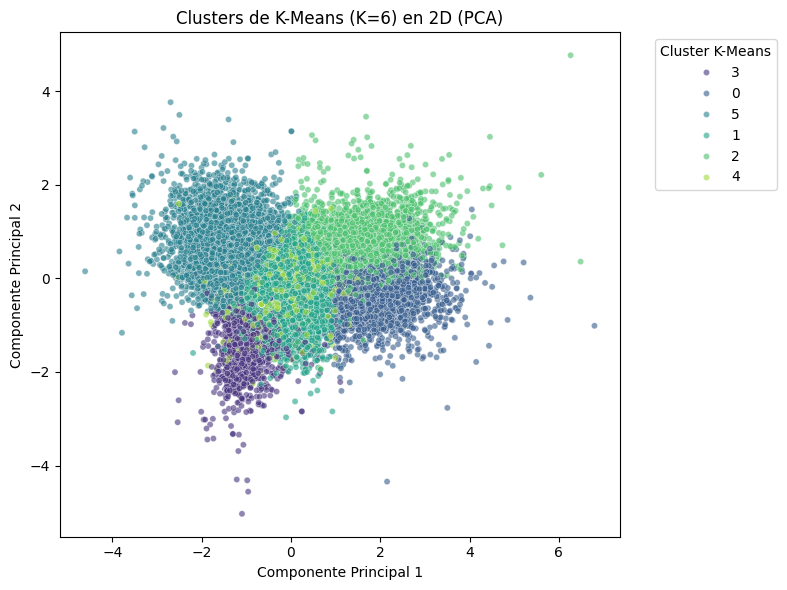

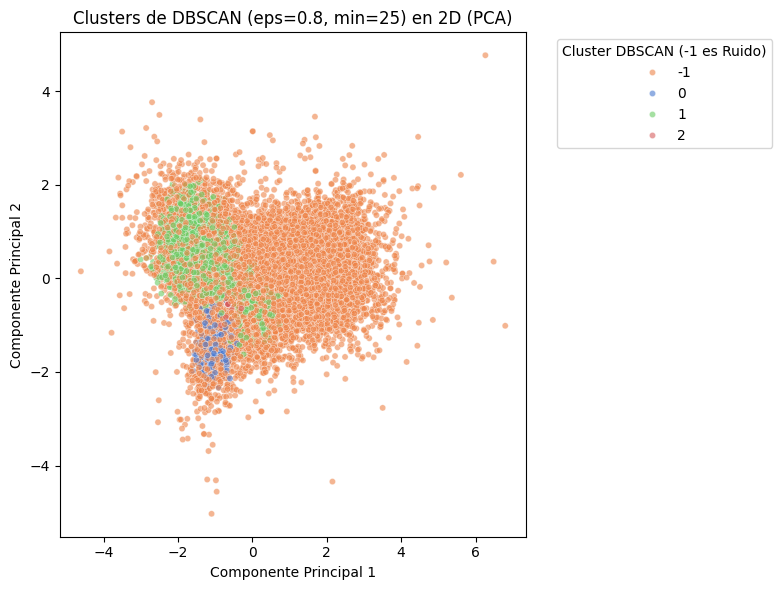

In [ ]:

kmeans_final = KMeans(n_clusters=6, random_state=9, n_init=10)
labels_kmeans = kmeans_final.fit_predict(vectores_docs)
dbscan_final = DBSCAN(eps=0.8, min_samples=25, n_jobs=-1)
labels_dbscan = dbscan_final.fit_predict(vectores_docs)

#reduciendo dimensionalidad
pca = PCA(n_components=2, random_state=9)
vectores_2d = pca.fit_transform(vectores_docs)

#df para graficar
df_viz = pd.DataFrame(vectores_2d, columns=['pc1', 'pc2'])
df_viz['cluster_kmeans'] = labels_kmeans.astype(str)
df_viz['cluster_dbscan'] = labels_dbscan.astype(str)


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_viz,
    x='pc1',
    y='pc2',
    hue='cluster_kmeans',
    palette='viridis',
    alpha=0.6,
    s=20 )
plt.title('Clusters de K-Means (K=6) en 2D (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster K-Means', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
separador()
#dbscan
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_viz,
    x='pc1',
    y='pc2',
    hue='cluster_dbscan',
    palette='muted',
    alpha=0.6,
    s=20)
plt.title('Clusters de DBSCAN (eps=0.8, min=25) en 2D (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
#ordenar ruido
handles, labels = plt.gca().get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: int(labels[i]) if labels[i] != '-1' else -1)
plt.legend([handles[i] for i in order], [labels[i] for i in order], title='Cluster DBSCAN (-1 es Ruido)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Wordcloud

................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Wordcloud para kmeans ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 




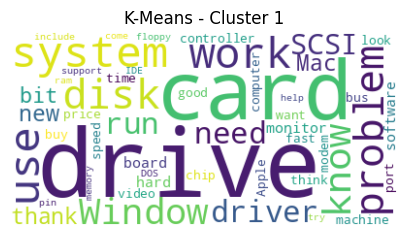

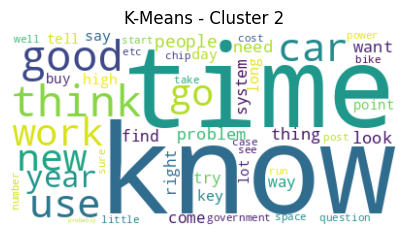

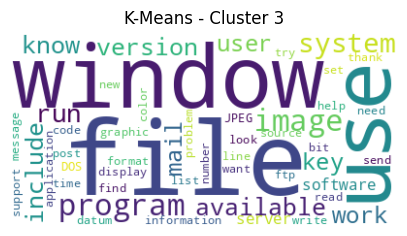

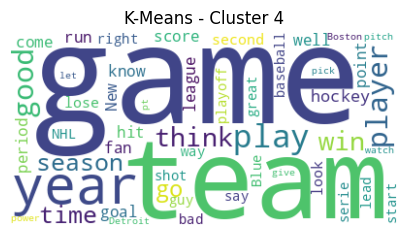

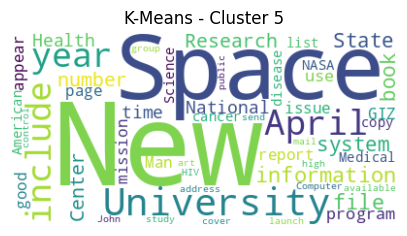

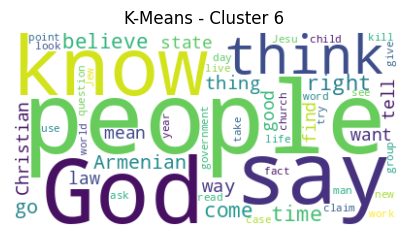

In [ ]:
textos_procesados = [' '.join(doc) for doc in docs_tokenizados]
df_textos = pd.DataFrame({'texto': textos_procesados,
                          'cluster_kmeans': labels_kmeans,
                          'cluster_dbscan': labels_dbscan})
wc = WordCloud(background_color='white', max_words=50, collocations=False, random_state=9)

header('Wordcloud para kmeans')
for i in range(6):
    plt.figure(figsize=(5, 5))
    texto_cluster = ' '.join(df_textos[df_textos['cluster_kmeans'] == i]['texto'])
    nube = wc.generate(texto_cluster)
    plt.imshow(nube, interpolation='bilinear')
    plt.title(f'K-Means - Cluster {i+1}')
    plt.axis('off')
    plt.show()




................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Wordcloud para dbscan ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 




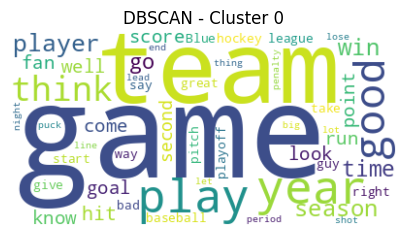

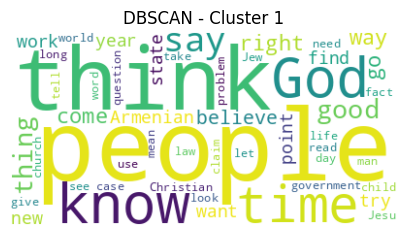

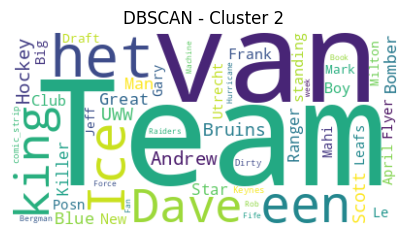

In [ ]:
header('Wordcloud para dbscan')
cluster_ids_dbscan = sorted(list(set(labels_dbscan)))
for cluster_id in cluster_ids_dbscan:
    if cluster_id == -1:
        continue
    plt.figure(figsize=(5, 5))
    texto_cluster = ' '.join(df_textos[df_textos['cluster_dbscan'] == cluster_id]['texto'])
    nube = wc.generate(texto_cluster)
    plt.imshow(nube, interpolation='bilinear')
    plt.title(f'DBSCAN - Cluster {cluster_id}')
    plt.axis('off')
    plt.show()